### [Mean-Reversion Strategies: How Stock Returns Drive Profits](https://medium.com/@technicalAnalysis/cf739eb837c3)

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import shapiro

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(suppress=True, precision=4)

pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('fivethirtyeight')

%autosave 10

Autosaving every 10 seconds


In [2]:
def mean_reversion_strategy(close, window: int = 20, z_entry = 1.5, z_exit = 0.0, fees = 0.001):
  df = pd.DataFrame({"close": close})
  df["ma"]  = df["close"].rolling(window).mean().shift(1)
  df["std"] = df["close"].rolling(window).std().shift(1)
  df["zscore"] = (df["close"] - df["ma"]) / df["std"]
  df["signal"] = 0
  df.loc[df["zscore"] < -z_entry,  "signal"] = 1
  df.loc[df["zscore"] >  z_entry,  "signal"] = -1
  df.loc[df["zscore"].abs() < z_exit, "signal"] = 0
  raw_signal = df["signal"].copy().astype(float)
  raw_signal[raw_signal == 0] = np.nan
  exit_mask = df["zscore"].abs() < z_exit
  raw_signal[exit_mask] = 0
  df["position"] = raw_signal.ffill().fillna(0)
  df["daily_return"] = df["close"].pct_change()
  position_change = df["position"].diff().abs()
  df["trade_cost"] = position_change * fees
  df["strategy_return"] = df["position"].shift(1) * df["daily_return"] - df["trade_cost"]
  df["cumulative_return"] = (1 + df["strategy_return"]).cumprod().pct_change() * 100
  return df.dropna(subset=["cumulative_return"])

Sector: Tech
	AAPL
	MSFT
	GOOGL
	AMZN
	NVDA
	META
	TSLA
	AVGO
	ORCL
	AMD
	INTC
	QCOM
	TXN
Sector: Finance
	JPM
	BAC
	WFC
	GS
	MS
	C
	BLK
	AXP
	V
	MA
	COF
	SCHW
	USB
	PNC
	TFC
Sector: Healthcare
	JNJ
	UNH
	PFE
	MRK
	ABBV
	LLY
	TMO
	ABT
	MDT
	BMY
	AMGN
	GILD
	ISRG
	VRTX
	REGN
Sector: Consumption
	WMT
	HD
	TGT
	COST
	LOW
	MCD
	SBUX
	NKE
	LULU
	TJX
	AMZN
	EBAY
	ETSY
	BKNG
	MAR
Sector: Energy
	XOM
	CVX
	COP
	SLB
	EOG
	MPC
	VLO
	PSX
	OXY
Sector: Industry
	CAT
	DE
	HON
	GE
	MMM
	UPS
	FDX
	LMT
	RTX
	BA
Sector: Telecom
	T
	VZ
	TMUS
	NFLX
	DIS
	CMCSA
	WBD
Sector: Other
	BRK-B
	SPGI
	MCO
	ICE
	CME


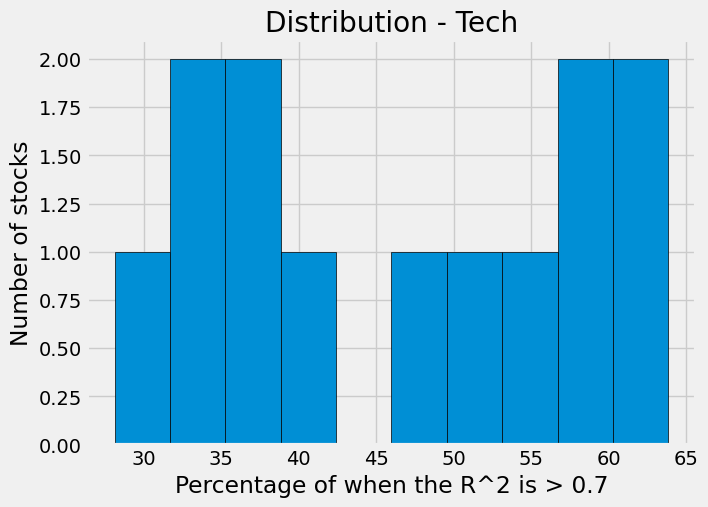

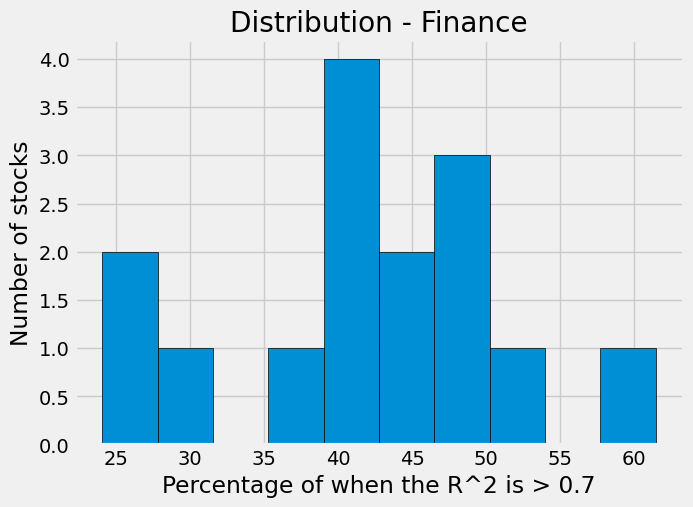

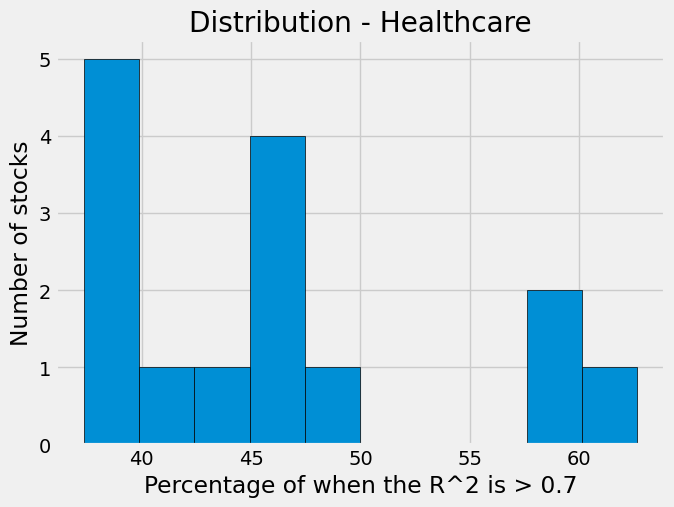

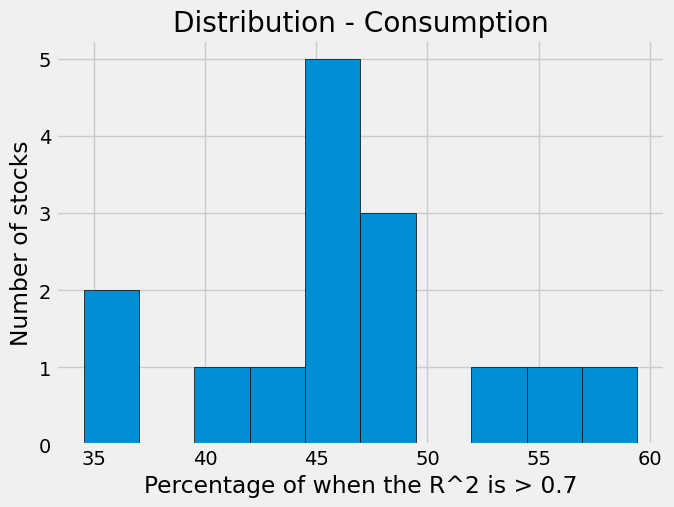

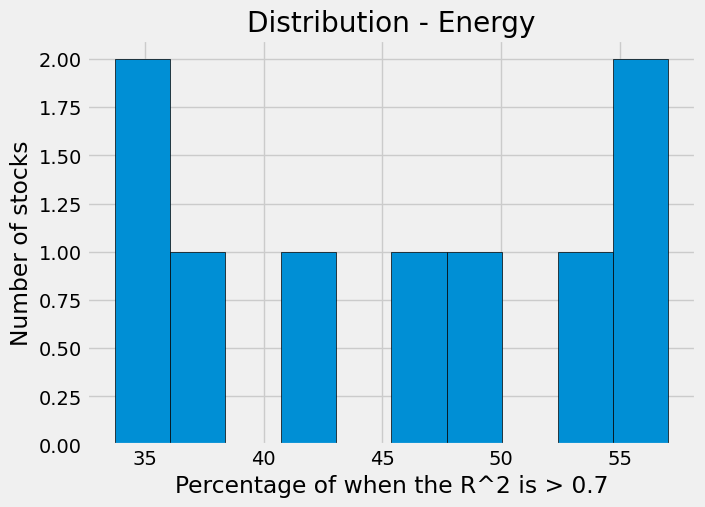

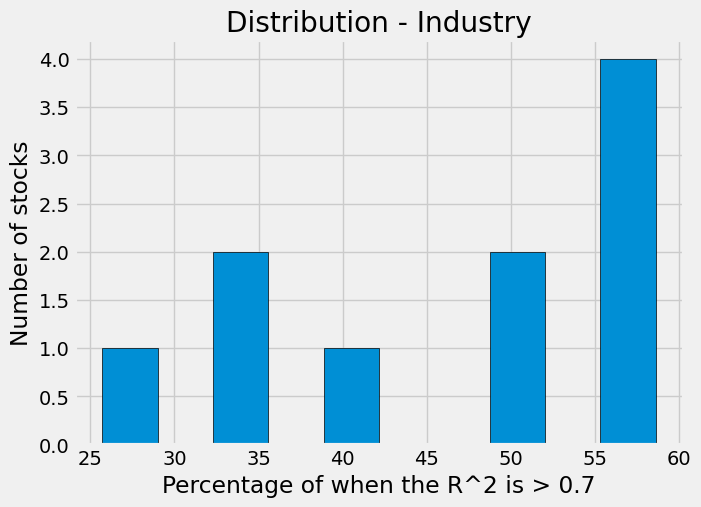

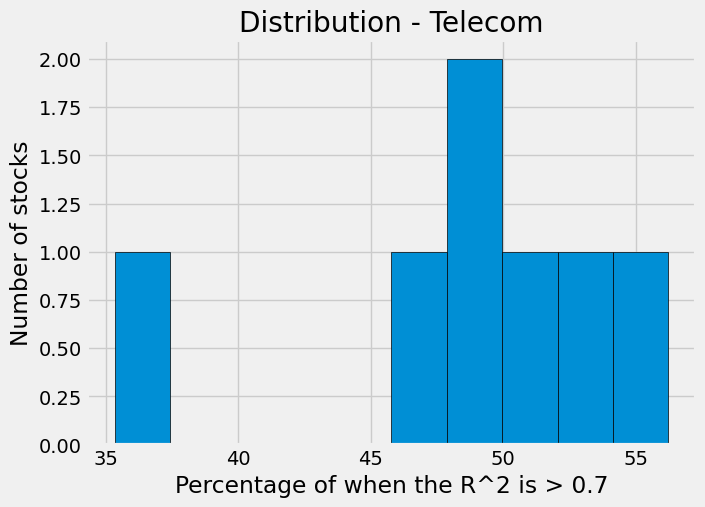

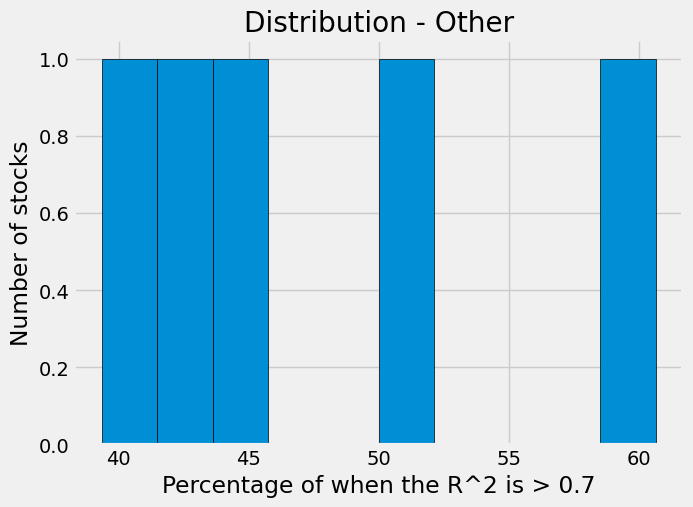

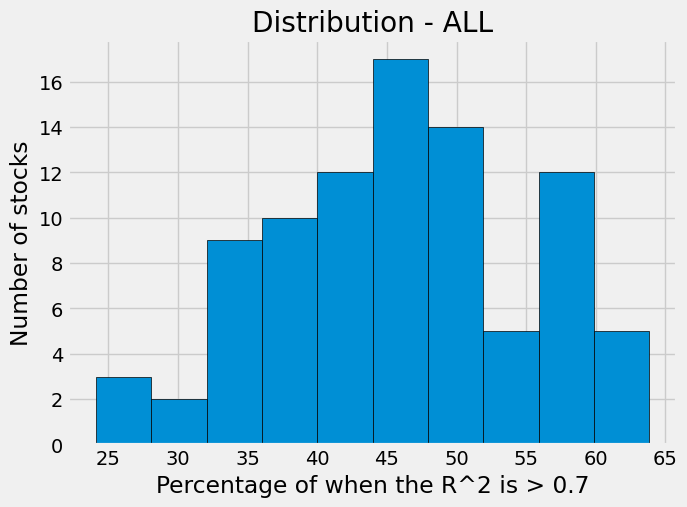

Test statistic: 0.9834
P-value: 0.3165
Mean : 45.86886873336041%
Standard deviation : 9.178685499978185%


In [3]:
tickers = {
  "Tech" : ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "AVGO", "ORCL", "AMD", "INTC", "QCOM", "TXN"],
  "Finance" : ["JPM", "BAC", "WFC", "GS", "MS", "C", "BLK", "AXP", "V", "MA", "COF", "SCHW", "USB", "PNC", "TFC"],
  "Healthcare" : ["JNJ", "UNH", "PFE", "MRK", "ABBV", "LLY", "TMO", "ABT", "MDT", "BMY", "AMGN", "GILD", "ISRG", "VRTX", "REGN"],
  "Consumption" : ["WMT", "HD", "TGT", "COST", "LOW", "MCD", "SBUX", "NKE", "LULU", "TJX", "AMZN", "EBAY", "ETSY", "BKNG", "MAR"],
  "Energy" : ["XOM", "CVX", "COP", "SLB", "EOG", "MPC", "VLO", "PSX", "OXY"],
  "Industry" : ["CAT", "DE", "HON", "GE", "MMM", "UPS", "FDX", "LMT", "RTX", "BA"],
  "Telecom" : ["T", "VZ", "TMUS", "NFLX", "DIS", "CMCSA", "WBD"],
  "Other" : ["BRK-B", "SPGI", "MCO", "ICE", "CME"]
}

list_list_distribution = []
for sector in tickers.keys():
  list_distribution = []
  print(f"Sector: {sector}")
  for ticker in tickers[sector]:
    print(f"\t{ticker}")
    data = yf.download(ticker, period="1y", auto_adjust=True, progress=False, multi_level_index=False)
    pct_change_asset = data["Close"].pct_change() * 100
    result = mean_reversion_strategy(data["Close"].squeeze())
    rolling_corr = result["cumulative_return"].rolling(20).corr(pct_change_asset.squeeze().reindex(result.index)) ** 2
    list_distribution.append(100*len([el for el in rolling_corr if el > 0.7])/len(rolling_corr.index))
  list_list_distribution.append((list_distribution, sector))


for list_distribution, sector in list_list_distribution:
  plt.figure(figsize=(7, 5))
  plt.hist(list_distribution, bins=10, edgecolor='black')
  plt.xlabel("Percentage of when the R^2 is > 0.7")
  plt.ylabel("Number of stocks")
  plt.title(f"Distribution - {sector}")
  plt.show()


list_total_distribution = list_list_distribution[0][0]
for i, el in enumerate(list_list_distribution):
  if i != 0:
    list_total_distribution += el[0]
np_list_total_distribution = np.array(list_total_distribution)

plt.figure(figsize=(7, 5))
plt.hist(list_total_distribution, bins=10, edgecolor='black')
plt.xlabel("Percentage of when the R^2 is > 0.7")
plt.ylabel("Number of stocks")
plt.title(f"Distribution - ALL")
plt.show()


# Shapiro-Wilk test :
statistique, p_value = shapiro(list_total_distribution)
print(f"Test statistic: {statistique:.4f}")
print(f"P-value: {p_value:.4f}")

# Parameters of the distribution
print(f"Mean : {np_list_total_distribution.mean()}%")
print(f"Standard deviation : {np_list_total_distribution.std()}%")